In [1]:
import bench_pennylane
import bench_qiskit

import bench_tensorflow
import bench_torch
import bench_numpy

import bench_tempo_py
import bench_tempo_cpp_collect

import numpy as np
import gc

In [2]:
# Gather raw benchmark data

benchmark_modules = {
    "pennylane": bench_pennylane,
    "qiskit": bench_qiskit,

    "tensorflow": bench_tensorflow,
    "torch": bench_torch,
    "numpy": bench_numpy,

    "tempo-py": bench_tempo_py,
    "tempo-cpp": bench_tempo_cpp_collect,
}

benchmark_results = {}

for name, module in benchmark_modules.items():
    print(f"Running benchmarks for {module.__name__}...")
    theta_results, expval_results = module.benchmark()
    benchmark_results[name] = {
        "theta": theta_results,
        "expval": expval_results,
    }
    gc.collect()

Running benchmarks for bench_pennylane...
Running benchmarks for bench_qiskit...
Running benchmarks for bench_tensorflow...


I0000 00:00:1773946549.519084  239671 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9374 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Running benchmarks for bench_torch...
Running benchmarks for bench_numpy...
Running benchmarks for bench_tempo_py...
Running benchmarks for bench_tempo_cpp_collect...


In [3]:
# Process benchmark data

data_theta = {}

def push_theta_time(name, n, time):
    if name not in data_theta:
        data_theta[name] = {}
    if "theta" not in data_theta[name]:
        data_theta[name]["theta"] = {}
    data_theta[name]["theta"][n] = time

data_expval = {}

def push_expval_time(backend, n, time):
    if backend not in data_expval:
        data_expval[backend] = {}
    if "expval" not in data_expval[backend]:
        data_expval[backend]["expval"] = {}
    data_expval[backend]["expval"][n] = time

for name, results in benchmark_results.items():
    theta_results = results["theta"]
    expval_results = results["expval"]
 
    for n, time in theta_results:
        push_theta_time(name, n, time)        

    for n, backend, expval, time in expval_results:
        push_expval_time(backend, n, time)

In [17]:
# Plotting

import matplotlib.pyplot as plt

colors = [
    "#097e0e", # pennylane
    "#4dd869",
    '#2ca02c',

    "#f2513f", # qiskit
    "#f75e34",
    "#f47c26",
    "#ff8049",
    "#f5ae85",
    "#d7910d",
    "#efbf2d",
    "#f9cf16",

    '#FF55FF', # manual-tn others
    "#D52BFF",
    "#7228FC",

    "#27BAFE", # manual-tn tempo
    "#7CF8FF"
]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', colors)

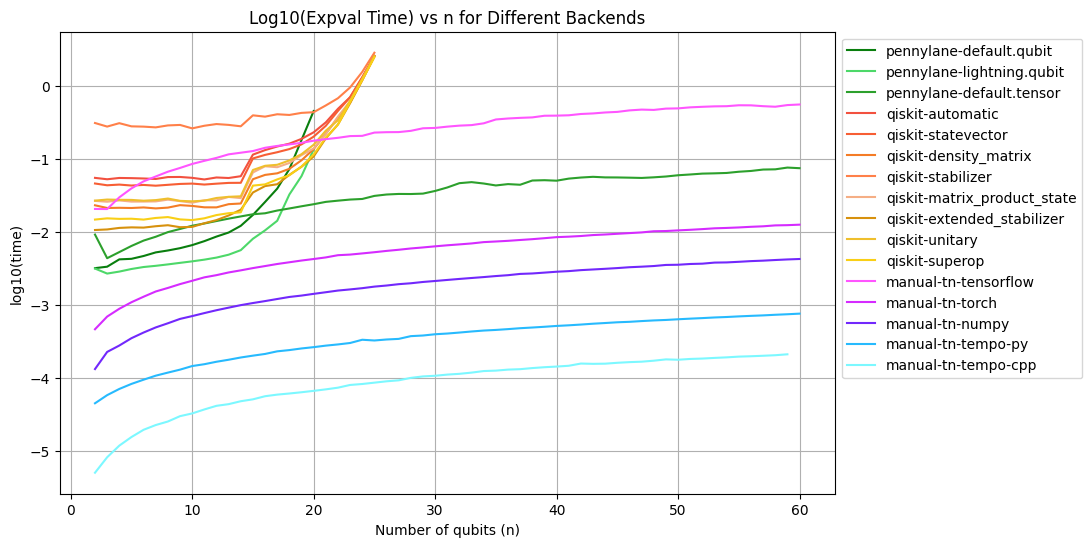

In [18]:
# Plot log(expval_time) vs n for each backend

plt.figure(figsize=(10, 6))
for name, results in data_expval.items():
    n_values = sorted(results["expval"].keys())
    times = [results["expval"][n] for n in n_values]
    plt.plot(n_values, np.log10(times), label=name)
plt.xlabel("Number of qubits (n)")
plt.ylabel("log10(time)")
plt.title("Log10(Expval Time) vs n for Different Backends")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

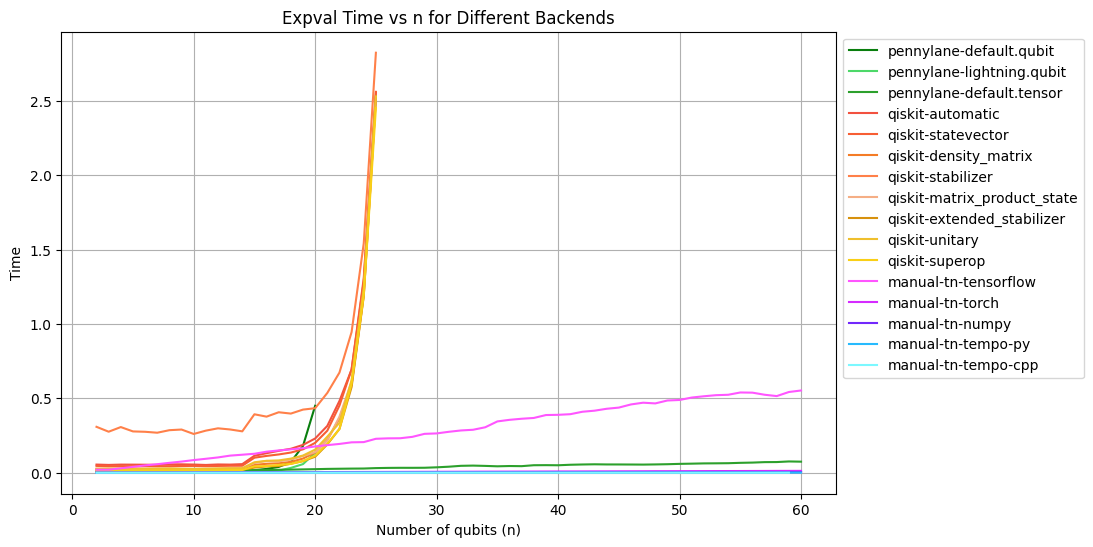

In [8]:
# Plot expval_time vs n for each backend

plt.figure(figsize=(10, 6))
for name, results in data_expval.items():
    n_values = sorted(results["expval"].keys())
    times = [results["expval"][n] for n in n_values]
    plt.plot(n_values, times, label=name)
plt.xlabel("Number of qubits (n)")
plt.ylabel("Time")
plt.title("Expval Time vs n for Different Backends")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

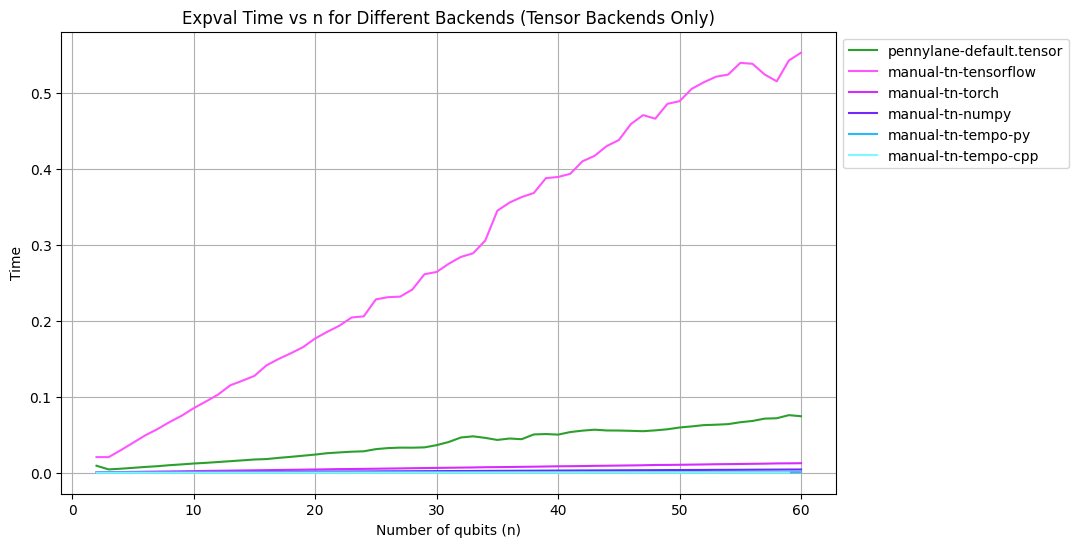

In [15]:
# Plot expval_time vs n for tensor backends

colors = [
    '#2ca02c', # pennylane

    '#FF55FF', # manual-tn others
    "#D52BFF",
    "#7228FC",

    "#27BAFE", # manual-tn tempo
    "#7CF8FF"
]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', colors)

plt.figure(figsize=(10, 6))
for name, results in data_expval.items():
    if "-tn-" in name or "tensor" in name:
        n_values = sorted(results["expval"].keys())
        times = [results["expval"][n] for n in n_values]
        plt.plot(n_values, times, label=name)
plt.xlabel("Number of qubits (n)")
plt.ylabel("Time")
plt.title("Expval Time vs n for Different Backends (Tensor Backends Only)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

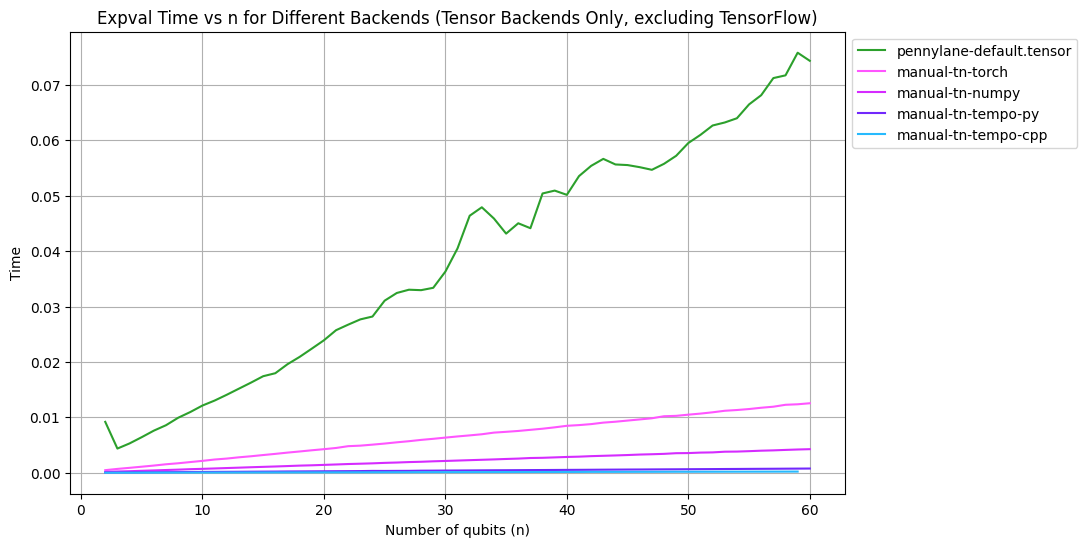

In [14]:
# Plot expval_time vs n for tensor backends (except tensorflow)

colors = [
    '#2ca02c', # pennylane

    "#D52BFF", # manual-tn others
    "#7228FC",

    "#27BAFE", # manual-tn tempo
    "#7CF8FF"
]

plt.figure(figsize=(10, 6))
for name, results in data_expval.items():
    if ("-tn-" in name or "tensor" in name) and "tensorflow" not in name:
        n_values = sorted(results["expval"].keys())
        times = [results["expval"][n] for n in n_values]
        plt.plot(n_values, times, label=name)
plt.xlabel("Number of qubits (n)")
plt.ylabel("Time")
plt.title("Expval Time vs n for Different Backends (Tensor Backends Only, excluding TensorFlow)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()